In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_ss2030 = pd.read_csv('/Users/amirah/Desktop/NLP_f/row_data/Arabic Sentiment Analysis Dataset - SS2030.csv')
df_training_1 = pd.read_csv('row_data/training_data (1).csv')
df_training = pd.read_csv('/Users/amirah/Desktop/NLP_f/row_data/training_data.csv')

توحيد الاعمده

In [ ]:
df_ss2030 = df_ss2030.rename(columns={'text': 'tweet', 'Sentiment': 'label'})
df_training_1 = df_training_1.rename(columns={'sentiment': 'label'})
df_training = df_training.rename(columns={'sentiment': 'label'})

EDA

info


In [16]:
print("=== SS2030: BASIC INFO ===")
print(df_ss2030.shape)
print(df_ss2030.columns)
df_ss2030.info()

=== SS2030: BASIC INFO ===
(4252, 2)
Index(['tweet', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   4252 non-null   object
 1   label   4252 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 66.6+ KB


In [17]:
print("=== TRAINING_1: BASIC INFO ===")
print(df_training_1.shape)
print(df_training_1.columns)
df_training_1.info()

=== TRAINING_1: BASIC INFO ===
(12548, 4)
Index(['tweet', 'sarcasm', 'label', 'dialect'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12548 entries, 0 to 12547
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tweet    12548 non-null  object
 1   sarcasm  12548 non-null  bool  
 2   label    12548 non-null  object
 3   dialect  12548 non-null  object
dtypes: bool(1), object(3)
memory usage: 306.5+ KB


In [18]:
print("=== TRAINING: BASIC INFO ===")
print(df_training.shape)
print(df_training.columns)
df_training.info()

=== TRAINING: BASIC INFO ===
(12548, 4)
Index(['tweet', 'sarcasm', 'label', 'dialect'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12548 entries, 0 to 12547
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tweet    12548 non-null  object
 1   sarcasm  12548 non-null  bool  
 2   label    12548 non-null  object
 3   dialect  12548 non-null  object
dtypes: bool(1), object(3)
memory usage: 306.5+ KB


 Missing values

In [19]:
print("=== SS2030: NULLS ===")
print(df_ss2030.isnull().sum())

=== SS2030: NULLS ===
tweet    0
label    0
dtype: int64


In [20]:
print("=== TRAINING_1: NULLS ===")
print(df_training_1.isnull().sum())

=== TRAINING_1: NULLS ===
tweet      0
sarcasm    0
label      0
dialect    0
dtype: int64


In [27]:
print("=== TRAINING: NULLS ===")
print(df_training.isnull().sum())

=== TRAINING: NULLS ===
tweet      0
sarcasm    0
label      0
dialect    0
dtype: int64


DUPLICATES

In [21]:
print("=== SS2030: DUPLICATES ===")
print(df_ss2030.duplicated().sum())

=== SS2030: DUPLICATES ===
38


In [22]:
print("=== TRAINING_1: DUPLICATES ===")
print(df_training_1.duplicated().sum())

=== TRAINING_1: DUPLICATES ===
16


In [28]:
print("=== TRAINING: DUPLICATES ===")
print(df_training.duplicated().sum())

=== TRAINING: DUPLICATES ===
16


LABEL DISTRIBUTION

=== SS2030: LABEL DISTRIBUTION ===
label
1    2436
0    1816
Name: count, dtype: int64


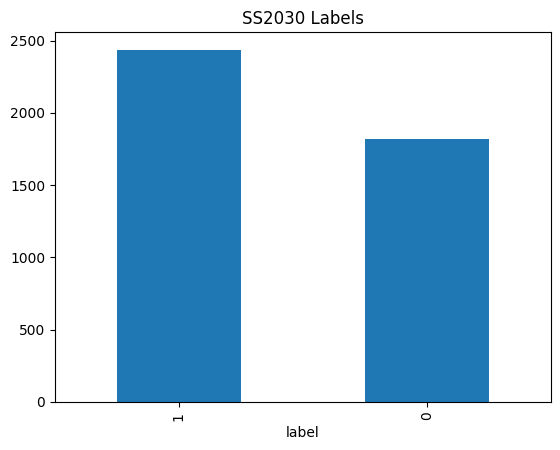

In [23]:
print("=== SS2030: LABEL DISTRIBUTION ===")
print(df_ss2030['label'].value_counts())

df_ss2030['label'].value_counts().plot(kind='bar')
plt.title("SS2030 Labels")
plt.show()

=== TRAINING_1: LABEL DISTRIBUTION ===
label
NEU    5747
NEG    4621
POS    2180
Name: count, dtype: int64


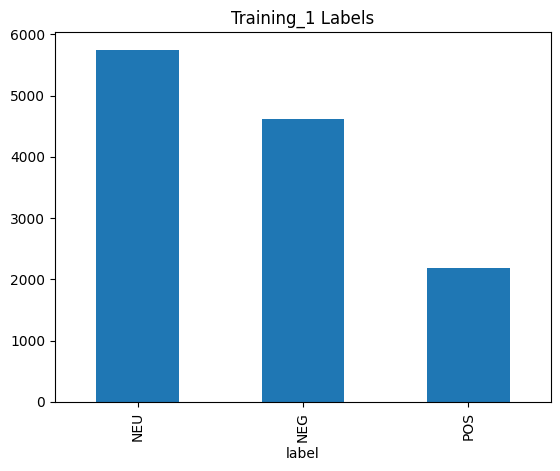

In [24]:
print("=== TRAINING_1: LABEL DISTRIBUTION ===")
print(df_training_1['label'].value_counts())

df_training_1['label'].value_counts().plot(kind='bar')
plt.title("Training_1 Labels")
plt.show()

=== TRAINING: LABEL DISTRIBUTION ===
label
NEU    5747
NEG    4621
POS    2180
Name: count, dtype: int64


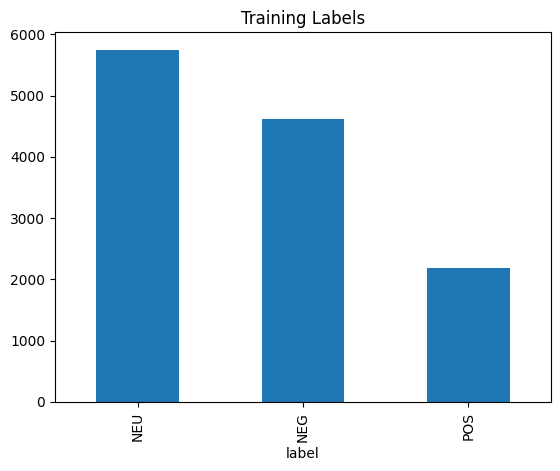

In [29]:
print("=== TRAINING: LABEL DISTRIBUTION ===")
print(df_training['label'].value_counts())

df_training['label'].value_counts().plot(kind='bar')
plt.title("Training Labels")
plt.show()

TEXT LENGTH

=== SS2030: TEXT LENGTH ===
count    4252.000000
mean       23.163217
std        14.328790
min         1.000000
25%        11.000000
50%        20.000000
75%        35.000000
max        60.000000
Name: length, dtype: float64


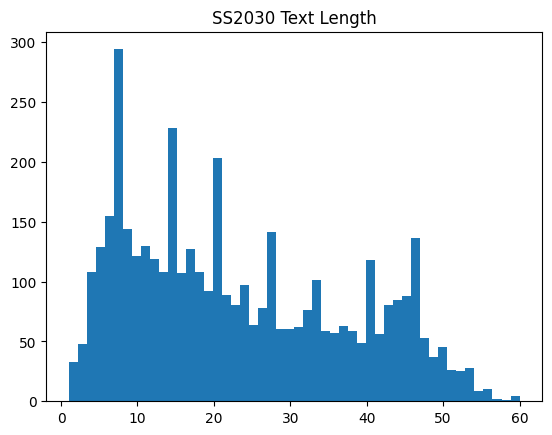

In [25]:
df_ss2030['length'] = df_ss2030['tweet'].astype(str).apply(lambda x: len(x.split()))

print("=== SS2030: TEXT LENGTH ===")
print(df_ss2030['length'].describe())

plt.hist(df_ss2030['length'], bins=50)
plt.title("SS2030 Text Length")
plt.show()

=== TRAINING_1: TEXT LENGTH ===
count    12548.000000
mean        15.043354
std          6.770960
min          1.000000
25%         10.000000
50%         15.000000
75%         20.000000
max         61.000000
Name: length, dtype: float64


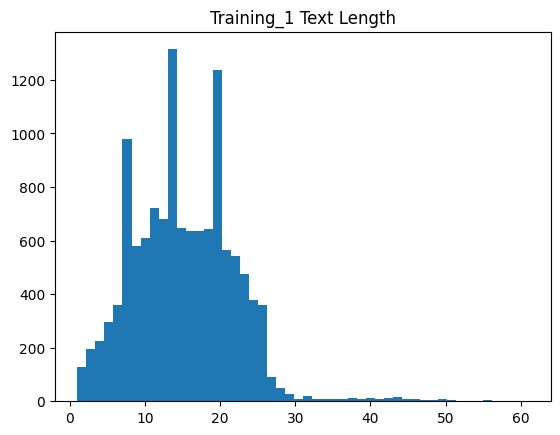

In [26]:
df_training_1['length'] = df_training_1['tweet'].astype(str).apply(lambda x: len(x.split()))

print("=== TRAINING_1: TEXT LENGTH ===")
print(df_training_1['length'].describe())

plt.hist(df_training_1['length'], bins=50)
plt.title("Training_1 Text Length")
plt.show()

=== TRAINING: TEXT LENGTH ===
count    12548.000000
mean        15.043354
std          6.770960
min          1.000000
25%         10.000000
50%         15.000000
75%         20.000000
max         61.000000
Name: length, dtype: float64


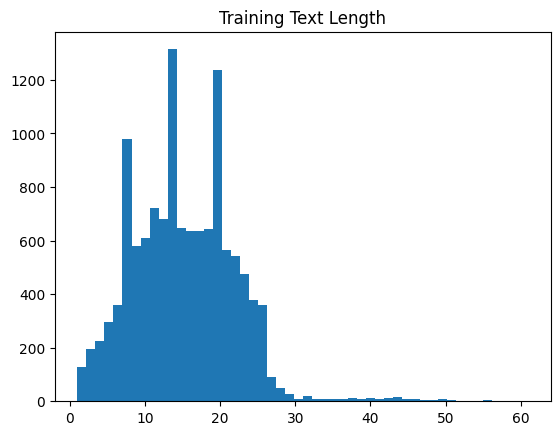

In [30]:
df_training['length'] = df_training['tweet'].astype(str).apply(lambda x: len(x.split()))

print("=== TRAINING: TEXT LENGTH ===")
print(df_training['length'].describe())

plt.hist(df_training['length'], bins=50)
plt.title("Training Text Length")
plt.show()